## Population - GDP data analysis

**Datasets:**
* Global_Population.csv
* Global_GDP.csv

**Task A: Correlation**   
1. Pre-process the data – mean population of each country and mean per capita GDP (from 2001 to 2021) by making some arrangements for the missing values. 
2. Investigate any correlation between the mean population of each country and the mean per capita GDP (from 2001 to 2021). Very briefly, interpret the generated plot. 
3. Evaluate the Pearson Correlation Coefficient.

**Task B: Regression**

Perform linear regression, where the independent variable is the mean population of each country (from 2001 to 2021) and dependent variable is mean per capita GDP (from 2001 to 2021).


### Importing packages

In [107]:
#Import packages
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import seaborn as sns

### Loading datasets

In [108]:
#Load  both dataset
population = pd.read_csv("Global_Population.csv")
gdp = pd.read_csv("Global_GDP.csv")


### Data Overview: Population

In [51]:
# Quick view of the population dataset
population.head()

,Country Name,Country Code,Series Name,Series Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54211,55438,56225,56695,57032,57360,...,102560,103159,103774,104341,104872,105366,105845,106314,NaN,NaN
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,8996967,9169406,9351442,9543200,9744772,9956318,...,31161378,32269592,33370804,34413603,35383028,36296111,37171922,38041757,38928341,39835000
2,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130836765,134159786,137614644,141202036,144920186,148769974,...,547482863,562601578,578075373,593871847,609978946,626392880,643090131,660046272,677243299,694664000
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,96396419,98407221,100506960,102691339,104953470,107289875,...,370243017,380437896,390882979,401586651,412551299,423769930,435229381,446911598,458803476,470898000
4,Albania,ALB,"Population, total",SP.POP.TOTL,1608800,1659800,1711319,1762621,1814135,1864791,...,2900401,2895092,2889104,2880703,2876101,2873457,2866376,2854191,2837743,2832000


In [52]:
population.tail()

,Country Name,Country Code,Series Name,Series Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270,Data from database: Population estimates and p...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
271,Last Updated: 12/17/2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Country names have missing infromation but also mistakenly uploaded footer informatation. These should be removed one by one. 

In [54]:
#Removing rows with missing countries
population = population.dropna(subset=['Country Name'])

In [55]:
#Removing footer information via indexes
population = population.drop(index=[270, 271])

In [57]:
#Validate 
population['Country Name'].isna().sum()

np.int64(0)

All non available and unidentified country names have been removed.

In [61]:
#Dataset dimensions
population.shape

(267, 66)

In [62]:
# 1.2 Variable types
population.info()

<class 'pandas.core.frame.DataFrame'>
Index: 267 entries, 0 to 266
Data columns (total 66 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Name  267 non-null    object
 1   Country Code  267 non-null    object
 2   Series Name   267 non-null    object
 3   Series Code   267 non-null    object
 4   1960          267 non-null    object
 5   1961          267 non-null    object
 6   1962          267 non-null    object
 7   1963          267 non-null    object
 8   1964          267 non-null    object
 9   1965          267 non-null    object
 10  1966          267 non-null    object
 11  1967          267 non-null    object
 12  1968          267 non-null    object
 13  1969          267 non-null    object
 14  1970          267 non-null    object
 15  1971          267 non-null    object
 16  1972          267 non-null    object
 17  1973          267 non-null    object
 18  1974          267 non-null    object
 19  1975         

### Data Quality Assessment - Population

In [65]:
#Missigness
population.isnull().sum()

Country Name    0
Country Code    0
Series Name     0
Series Code     0
1960            0
               ..
2017            0
2018            0
2019            0
2020            1
2021            1
Length: 66, dtype: int64

In [ ]:
# Duplicates values in the dataset
population.duplicated().sum()

np.int64(0)

Population data inspection: 
* 272 observations, 66 columns, all categorical
* Year range 1960-2021, but 2 missing values identified for two recent years
* Years are categorical and need to be convtered into nummerical to calulate the means
* No duplicated values found

### Deep dive into missingness and duplicates

In [67]:
#Check if duplicated countries exists
population[population.duplicated(subset=['Country Name'], keep=False)]

,Country Name,Country Code,Series Name,Series Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54211,55438,56225,56695,57032,57360,...,102560,103159,103774,104341,104872,105366,105845,106314,NaN,NaN
13,Aruba,ABW,"Population, total",SP.POP.TOTL,54208,55434,56234,56699,57029,57357,...,102565,103165,103776,104339,104865,105361,105846,106310,106766,107000


In [68]:
#Check if duplicated country code exists
population[population.duplicated(subset=['Country Code'], keep=False)]

,Country Name,Country Code,Series Name,Series Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54211,55438,56225,56695,57032,57360,...,102560,103159,103774,104341,104872,105366,105845,106314,NaN,NaN
13,Aruba,ABW,"Population, total",SP.POP.TOTL,54208,55434,56234,56699,57029,57357,...,102565,103165,103776,104339,104865,105361,105846,106310,106766,107000


Aruba was recorded twice, with the same country code and series name and code. Inspecting the values overlap to decide which one to keep.

In [69]:
#Comparing Aruba values
aruba.iloc[0].compare(aruba.iloc[1])

,self,other
1960,54211,54208
1961,55438,55434
1962,56225,56234
1963,56695,56699
1964,57032,57029
1965,57360,57357
1966,57715,57702
1967,58055,58044
1968,58386,58377
1969,58726,58734


Given marginal differences between the recorded values, and two missing years in 2020 and 2021, first Aruba observation will be droppped.

## Preprocessing

### Duplicated country 

In [70]:
#Removing duplicated Aruba with missing values
population = population.drop(index=[0])

In [71]:
#Validate if only one correct Aruba is left
population[population['Country Name'] == 'Aruba']

,Country Name,Country Code,Series Name,Series Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
13,Aruba,ABW,"Population, total",SP.POP.TOTL,54208,55434,56234,56699,57029,57357,...,102565,103165,103776,104339,104865,105361,105846,106310,106766,107000


### Year

Given that year values are stored as object we need to transform them into numerical values. First however, for easier preprocessing we are creating a 'years' object with year range 2001-2021 that are requiered for the analysis as a list to simplify conversion.

In [72]:
#Create years object for easy years sorting
years = [str(year) for year in range(2001, 2022)]

In [73]:
#verify the age range
[col for col in years if col not in population.columns]

[]

In [74]:
#First check missing values across the years
population[years].isnull().sum()

2001    0
2002    0
2003    0
2004    0
2005    0
2006    0
2007    0
2008    0
2009    0
2010    0
2011    0
2012    0
2013    0
2014    0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
dtype: int64

No missing values were detected per year, but we need to check whether there are any non-numeric values available.

In [75]:
# Checking if all years values contain values that can not be converted to numbers.

for year in years:
    non_numeric = pd.to_numeric(population[year], errors='coerce').isna() & population[year].notna()

    if non_numeric.any():
        print(year)
        print(population.loc[non_numeric,['Country Name', year]])

2001
       Country Name 2001
106       IBRD only   ..
109       IDA blend   ..
110        IDA only   ..
111       IDA total   ..
184  Not classified   ..
2002
       Country Name 2002
106       IBRD only   ..
109       IDA blend   ..
110        IDA only   ..
111       IDA total   ..
184  Not classified   ..
2003
       Country Name 2003
106       IBRD only   ..
109       IDA blend   ..
110        IDA only   ..
111       IDA total   ..
184  Not classified   ..
2004
       Country Name 2004
106       IBRD only   ..
109       IDA blend   ..
110        IDA only   ..
111       IDA total   ..
184  Not classified   ..
2005
       Country Name 2005
106       IBRD only   ..
109       IDA blend   ..
110        IDA only   ..
111       IDA total   ..
184  Not classified   ..
2006
       Country Name 2006
106       IBRD only   ..
109       IDA blend   ..
110        IDA only   ..
111       IDA total   ..
184  Not classified   ..
2007
       Country Name 2007
106       IBRD only   ..
109       IDA b

The year column stored all values as object becuase the missing observations were represented as '..', hence we can proceed with converting these to NaN.  Also some countries have 'no country' values. Further investigation requiered before dropping them.

### Converting the 2001–2021 columns

In [76]:
#Convert categorical years values into numerical values, values that could not be converted replace with NaN
population[years] = population[years].apply(pd.to_numeric, errors='coerce')

In [77]:
#Validation of the conversion
population[years].dtypes

2001    float64
2002    float64
2003    float64
2004    float64
2005    float64
2006    float64
2007    float64
2008    float64
2009    float64
2010    float64
2011    float64
2012    float64
2013    float64
2014    float64
2015    float64
2016    float64
2017    float64
2018    float64
2019    float64
2020    float64
2021    float64
dtype: object

In [78]:
#Check missing values per year
population[years].isnull().sum()

2001     5
2002     5
2003     5
2004     5
2005     5
2006     5
2007     5
2008     5
2009     5
2010     5
2011     5
2012     6
2013     6
2014     6
2015     6
2016     6
2017     6
2018     6
2019     6
2020     6
2021    10
dtype: int64

In [79]:
#Affected countries with missing values
population.loc[population[years].isnull().any(axis=1), ['Country Name'] + ['Country Code'] + years]

,Country Name,Country Code,2001,2002,2003,2004,2005,2006,2007,2008,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
25,Bermuda,BMU,62504.0,62912.0,63325.0,63740.0,64154.0,64523.0,64888.0,65273.0,...,64798.0,65001.0,65138.0,65237.0,64554.0,63873.0,63919.0,63913.0,63903.0,NaN
71,Eritrea,ERI,2374721.0,2481059.0,2600972.0,2719809.0,2826653.0,2918209.0,2996540.0,3062782.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,Greenland,GRL,56350.0,56609.0,56765.0,56911.0,56935.0,56774.0,56555.0,56328.0,...,56810.0,56483.0,56295.0,56114.0,56186.0,56172.0,56023.0,56225.0,56367.0,NaN
106,IBRD only,IBD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109,IDA blend,IDB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110,IDA only,IDX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111,IDA total,IDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
184,Not classified,INX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214,Sint Maarten (Dutch part),SXM,30600.0,30777.0,31472.0,32488.0,33011.0,33441.0,33811.0,33964.0,...,34640.0,36607.0,37685.0,38825.0,39969.0,40574.0,40654.0,40733.0,40812.0,NaN
228,St. Martin (French part),MAF,29847.0,30913.0,32055.0,33187.0,34252.0,35240.0,36138.0,36880.0,...,37012.0,36458.0,36018.0,35865.0,36061.0,36569.0,37264.0,38002.0,38659.0,NaN


After conversion some odd countries and 'non classsified' turned out to have non available values. I want to inspect them to decide whether these should be removed. 

In [ ]:
#Checking suspicious country names 
all_missing = population[years].isna().all(axis=1)

population.loc[all_missing, ['Country Name']]

,Country Name
106,IBRD only
109,IDA blend
110,IDA only
111,IDA total
184,Not classified


Confirmed the odd countries have ALL missing values for year. Proceeding with removing them.

In [81]:
#Removing Countries with all missing values from 2001-2021
population = population.loc[~all_missing]

In [84]:
#Validate
population[years].isna().all(axis=1).sum()

np.int64(0)

Checking whether other countries are missing any year values


In [89]:
#Checking year missignsess across 2001-2021

any_missing = population[years].isna().any(axis=1)

population.loc[any_missing, ['Country Name'] + years]

,Country Name,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
25,Bermuda,62504.0,62912.0,63325.0,63740.0,64154.0,64523.0,64888.0,65273.0,65636.0,...,64798.0,65001.0,65138.0,65237.0,64554.0,63873.0,63919.0,63913.0,63903.0,NaN
71,Eritrea,2374721.0,2481059.0,2600972.0,2719809.0,2826653.0,2918209.0,2996540.0,3062782.0,3119920.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,Greenland,56350.0,56609.0,56765.0,56911.0,56935.0,56774.0,56555.0,56328.0,56323.0,...,56810.0,56483.0,56295.0,56114.0,56186.0,56172.0,56023.0,56225.0,56367.0,NaN
214,Sint Maarten (Dutch part),30600.0,30777.0,31472.0,32488.0,33011.0,33441.0,33811.0,33964.0,34238.0,...,34640.0,36607.0,37685.0,38825.0,39969.0,40574.0,40654.0,40733.0,40812.0,NaN
228,St. Martin (French part),29847.0,30913.0,32055.0,33187.0,34252.0,35240.0,36138.0,36880.0,37380.0,...,37012.0,36458.0,36018.0,35865.0,36061.0,36569.0,37264.0,38002.0,38659.0,NaN


In [ ]:
#Inspecting the missigness pattern

for _, row in population.loc[
    population[years].isna().any(axis=1)
].iterrows():

    missing_years = row[years][row[years].isna()].index.tolist()
    print(row["Country Name"], missing_years)

Bermuda ['2021']
Eritrea ['2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021']
Greenland ['2021']
Sint Maarten (Dutch part) ['2021']
St. Martin (French part) ['2021']


Decision: since only 2021 values are missing, I am moviong ahead with calulating the mean for these Bermuda, Greenland, Sint Maarten and St. Martin based on 2001-2020 data. Given that Eritrea misses 10 out of 21 values, I am exluding the country form the list.

In [96]:
# Droping Eritrea
population = population.drop(index=71)

In [97]:
#Verify
population[population['Country Name'] == 'Eritrea']

,Country Name,Country Code,Series Name,Series Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,Mean_Population,Mean Population


In [101]:
#Saving cleaned preprocessed file
population.to_csv('Global_Population_Cleaned.csv', index=False)

### Calculate mean population


In [98]:
# Calulate the mean population across 2001 -2021 
population['Mean_Population'] = population[years].mean(axis=1, skipna=True)

In [99]:
#Inspect
population[['Country Name', 'Mean Population']].head()

,Country Name,Mean Population
1,Afghanistan,3.067118e+07
2,Africa Eastern and Southern,5.398680e+08
3,Africa Western and Central,3.647774e+08
4,Albania,2.930953e+06
5,Algeria,3.722809e+07


In [102]:
#Saving Mean Population file
mean_population = population[['Country Name', 'Mean Population']]

mean_population.to_csv('Mean_Population_2001_2021.csv', index=False)

In [115]:
mean_population.shape

(260, 2)

# Data Overview - GDP

In [109]:
# Quick view of the population dataset
gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.549721e+09,2.534637e+09,2.727850e+09,2.790849e+09,2.962905e+09,2.983637e+09,3.092430e+09,3.202189e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,1.929944e+10,1.970954e+10,2.147872e+10,2.571501e+10,2.351080e+10,2.679160e+10,...,9.427110e+11,9.498490e+11,9.635600e+11,9.837490e+11,9.186470e+11,8.720230e+11,9.842560e+11,1.011720e+12,1.008380e+12,9.188150e+11
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,...,1.780511e+10,1.990732e+10,2.014640e+10,2.049713e+10,1.913421e+10,1.811656e+10,1.875347e+10,1.805323e+10,1.879945e+10,2.011614e+10
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.040428e+10,1.112805e+10,1.194335e+10,1.267652e+10,1.383858e+10,1.486247e+10,...,6.709630e+11,7.275710e+11,8.207880e+11,8.514870e+11,7.607300e+11,6.905430e+11,6.837420e+11,7.416920e+11,7.945720e+11,7.845880e+11
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.117900e+11,1.280530e+11,1.367100e+11,1.457120e+11,1.161940e+11,1.011240e+11,1.221240e+11,1.013530e+11,8.941719e+10,5.837598e+10


In [110]:
gdp.tail()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
261,Kosovo,XKX,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,6.341737e+09,6.163785e+09,6.735731e+09,7.074658e+09,6.295820e+09,6.682833e+09,7.180813e+09,7.878509e+09,7.899879e+09,7.716925e+09
262,"Yemen, Rep.",YEM,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.272642e+10,3.540134e+10,4.041524e+10,4.322859e+10,4.244510e+10,3.131737e+10,2.684013e+10,2.160614e+10,NaN,NaN
263,South Africa,ZAF,GDP (current US$),NY.GDP.MKTP.CD,7.575397e+09,7.972997e+09,8.497997e+09,9.423396e+09,1.037400e+10,1.133440e+10,...,4.582020e+11,4.344010e+11,4.008860e+11,3.811990e+11,3.467100e+11,3.235860e+11,3.814490e+11,4.048420e+11,3.879350e+11,3.354420e+11
264,Zambia,ZMB,GDP (current US$),NY.GDP.MKTP.CD,7.130000e+08,6.962857e+08,6.931429e+08,7.187143e+08,8.394286e+08,1.082857e+09,...,2.345952e+10,2.550306e+10,2.803724e+10,2.714102e+10,2.125122e+10,2.095841e+10,2.587360e+10,2.631159e+10,2.330867e+10,1.811063e+10
265,Zimbabwe,ZWE,GDP (current US$),NY.GDP.MKTP.CD,1.052990e+09,1.096647e+09,1.117602e+09,1.159512e+09,1.217138e+09,1.311436e+09,...,1.410192e+10,1.711485e+10,1.909102e+10,1.949552e+10,1.996312e+10,2.054868e+10,1.758489e+10,1.811554e+10,1.928429e+10,1.805117e+10


In [113]:
#Dataset dimensions
gdp.shape

(266, 65)

In [112]:
gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 65 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            128 non-null    float64
 5   1961            134 non-null    float64
 6   1962            137 non-null    float64
 7   1963            137 non-null    float64
 8   1964            137 non-null    float64
 9   1965            148 non-null    float64
 10  1966            151 non-null    float64
 11  1967            154 non-null    float64
 12  1968            159 non-null    float64
 13  1969            159 non-null    float64
 14  1970            168 non-null    float64
 15  1971            171 non-null    float64
 16  1972            171 non-null    float64
 17  1973            171 non-null    flo

### Data Quality Assessment - GDP

In [116]:
gdp.isnull().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              138
                 ... 
2016               10
2017               10
2018               10
2019               13
2020               25
Length: 65, dtype: int64

In [117]:
gdp.duplicated().sum()

np.int64(0)

In [120]:
#Check if duplicated countries exists
gdp[gdp.duplicated(subset=['Country Name'], keep=False)]

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020


gdp data inspection: 
* 266 observations, 65 columns (missing 2021 year as opposed to population)
* Years values are stored as numeric
* A few missing values identified across year 
* No duplicated values found, no duplicated counturies found
* Data unitl 2020 as opposed to population till 2021 for population

### Year Preprocessing

In [135]:
#Check years range
years = [str(year) for year in range(2001, 2022)]

[col for col in years if col not in gdp.columns]

['2021']

In [144]:
#Create years object for gdp 2001-2020
gdp_years = [str(year) for year in range(2001, 2021)]

In [148]:
#Check year type
gdp[gdp_years].dtypes

2001    float64
2002    float64
2003    float64
2004    float64
2005    float64
2006    float64
2007    float64
2008    float64
2009    float64
2010    float64
2011    float64
2012    float64
2013    float64
2014    float64
2015    float64
2016    float64
2017    float64
2018    float64
2019    float64
2020    float64
dtype: object

In [145]:
#First check missing values across the years
gdp[gdp_years].isnull().sum()

2001    18
2002    13
2003    13
2004    13
2005    13
2006    12
2007    12
2008    11
2009    11
2010    10
2011     8
2012     9
2013     8
2014     8
2015     9
2016    10
2017    10
2018    10
2019    13
2020    25
dtype: int64

All year values are stores as numeric, so no conversion is needed. However, values are missing across different years. Now checking affected countries. 

In [151]:
#Affected countries with missing values
gdp.loc[gdp[gdp_years].isnull().any(axis=1), ['Country Name'] + ['Country Code'] + gdp_years]

,Country Name,Country Code,2001,2002,2003,2004,2005,2006,2007,2008,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,ABW,1.920112e+09,1.941341e+09,2.021229e+09,2.228492e+09,2.330726e+09,2.424581e+09,2.615084e+09,2.745251e+09,...,2.549721e+09,2.534637e+09,2.727850e+09,2.790849e+09,2.962905e+09,2.983637e+09,3.092430e+09,3.202189e+09,NaN,NaN
2,Afghanistan,AFG,NaN,4.055180e+09,4.515559e+09,5.226779e+09,6.209138e+09,6.971286e+09,9.747880e+09,1.010931e+10,...,1.780511e+10,1.990732e+10,2.014640e+10,2.049713e+10,1.913421e+10,1.811656e+10,1.875347e+10,1.805323e+10,1.879945e+10,2.011614e+10
6,Andorra,AND,1.546926e+09,1.755910e+09,2.361727e+09,2.894922e+09,3.159905e+09,3.456442e+09,3.952601e+09,4.085631e+09,...,3.629204e+09,3.188809e+09,3.193704e+09,3.271808e+09,2.789870e+09,2.896679e+09,3.000181e+09,3.218316e+09,3.155065e+09,NaN
11,American Samoa,ASM,NaN,5.120000e+08,5.240000e+08,5.090000e+08,5.000000e+08,4.930000e+08,5.180000e+08,5.600000e+08,...,5.700000e+08,6.400000e+08,6.380000e+08,6.430000e+08,6.730000e+08,6.710000e+08,6.120000e+08,6.390000e+08,6.480000e+08,7.090000e+08
38,Channel Islands,CHI,6.232906e+09,6.663669e+09,7.332245e+09,8.553643e+09,8.827273e+09,9.676173e+09,1.151461e+10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,Curacao,CUW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.038700e+09,3.131096e+09,3.147616e+09,3.158406e+09,3.151911e+09,3.122288e+09,3.116610e+09,3.127908e+09,3.101788e+09,2.595822e+09
52,Cayman Islands,CYM,NaN,NaN,NaN,NaN,NaN,4.200439e+09,4.466439e+09,4.586114e+09,...,4.186224e+09,4.291159e+09,4.405955e+09,4.563018e+09,4.708337e+09,4.909499e+09,5.166467e+09,5.522626e+09,5.935769e+09,5.591624e+09
69,Eritrea,ERI,7.523685e+08,7.293214e+08,8.702477e+08,1.109054e+09,1.098426e+09,1.211162e+09,1.317974e+09,1.380189e+09,...,2.065002e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,Faroe Islands,FRO,1.147655e+09,1.262670e+09,1.494012e+09,1.688238e+09,1.727793e+09,1.984445e+09,2.290134e+09,2.432416e+09,...,2.490808e+09,2.366301e+09,2.627050e+09,2.850744e+09,2.518096e+09,2.738833e+09,2.899226e+09,3.051341e+09,3.126293e+09,NaN
84,Gibraltar,GIB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [154]:
#Checking countries with missing GDP observations across 2001-2020
all_missing_gdp = gdp[gdp_years].isna().all(axis=1)

gdp.loc[all_missing_gdp, ['Country Name', 'Country Code']]

,Country Name,Country Code
84,Gibraltar,GIB
110,Not classified,INX
147,St. Martin (French part),MAF
193,"Korea, Dem. People's Rep.",PRK
199,French Polynesia,PYF
255,British Virgin Islands,VGB


In [169]:
#Removing Countries with all missing GDP values from 2001-2021
gdp = gdp.loc[~all_missing_gdp].copy()

In [170]:
#Validate
gdp[gdp_years].isna().all(axis=1).sum()

np.int64(0)

In [171]:
#Checking year with partial missingness across 2001-2021 (at least one missigness)
any_missing_gdp = gdp[gdp_years].isna().any(axis=1)

gdp.loc[any_missing_gdp, ['Country Name'] + gdp_years]

,Country Name,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,1.920112e+09,1.941341e+09,2.021229e+09,2.228492e+09,2.330726e+09,2.424581e+09,2.615084e+09,2.745251e+09,2.498883e+09,...,2.549721e+09,2.534637e+09,2.727850e+09,2.790849e+09,2.962905e+09,2.983637e+09,3.092430e+09,3.202189e+09,NaN,NaN
2,Afghanistan,NaN,4.055180e+09,4.515559e+09,5.226779e+09,6.209138e+09,6.971286e+09,9.747880e+09,1.010931e+10,1.241616e+10,...,1.780511e+10,1.990732e+10,2.014640e+10,2.049713e+10,1.913421e+10,1.811656e+10,1.875347e+10,1.805323e+10,1.879945e+10,2.011614e+10
6,Andorra,1.546926e+09,1.755910e+09,2.361727e+09,2.894922e+09,3.159905e+09,3.456442e+09,3.952601e+09,4.085631e+09,3.674410e+09,...,3.629204e+09,3.188809e+09,3.193704e+09,3.271808e+09,2.789870e+09,2.896679e+09,3.000181e+09,3.218316e+09,3.155065e+09,NaN
11,American Samoa,NaN,5.120000e+08,5.240000e+08,5.090000e+08,5.000000e+08,4.930000e+08,5.180000e+08,5.600000e+08,6.750000e+08,...,5.700000e+08,6.400000e+08,6.380000e+08,6.430000e+08,6.730000e+08,6.710000e+08,6.120000e+08,6.390000e+08,6.480000e+08,7.090000e+08
38,Channel Islands,6.232906e+09,6.663669e+09,7.332245e+09,8.553643e+09,8.827273e+09,9.676173e+09,1.151461e+10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,Curacao,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.038700e+09,3.131096e+09,3.147616e+09,3.158406e+09,3.151911e+09,3.122288e+09,3.116610e+09,3.127908e+09,3.101788e+09,2.595822e+09
52,Cayman Islands,NaN,NaN,NaN,NaN,NaN,4.200439e+09,4.466439e+09,4.586114e+09,4.281869e+09,...,4.186224e+09,4.291159e+09,4.405955e+09,4.563018e+09,4.708337e+09,4.909499e+09,5.166467e+09,5.522626e+09,5.935769e+09,5.591624e+09
69,Eritrea,7.523685e+08,7.293214e+08,8.702477e+08,1.109054e+09,1.098426e+09,1.211162e+09,1.317974e+09,1.380189e+09,1.856696e+09,...,2.065002e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,Faroe Islands,1.147655e+09,1.262670e+09,1.494012e+09,1.688238e+09,1.727793e+09,1.984445e+09,2.290134e+09,2.432416e+09,2.268388e+09,...,2.490808e+09,2.366301e+09,2.627050e+09,2.850744e+09,2.518096e+09,2.738833e+09,2.899226e+09,3.051341e+09,3.126293e+09,NaN
91,Greenland,1.086173e+09,1.169139e+09,1.558753e+09,1.822487e+09,1.849806e+09,2.013099e+09,2.249812e+09,2.499108e+09,2.529948e+09,...,2.684467e+09,2.609668e+09,2.684953e+09,2.842049e+09,2.499116e+09,2.707147e+09,2.851611e+09,3.040414e+09,2.982247e+09,NaN


In [ ]:
#Inspecting the missigness count

missing_count_gdp = gdp[gdp_years].isna().sum(axis=1)

gdp.loc[any_missing_gdp, ['Country Name']
].assign(
    Missing_Years = missing_count_gdp[any_missing_gdp]
).sort_values(
    'Missing_Years', 
    ascending=False
)

,Country Name,Missing_Years
38,Channel Islands,13
225,Sint Maarten (Dutch part),12
216,South Sudan,12
213,Somalia,12
51,Curacao,10
69,Eritrea,9
179,Nauru,9
261,Kosovo,7
254,"Venezuela, RB",6
52,Cayman Islands,5


Decision: Removing countries with more than 5 missing values, keeping country coverage of +75%.

In [181]:
# Dropping coutntries with Gpd missingness above 5
gdp = gdp.loc[missing_count_gdp <= 5].copy()

In [183]:
#Validate
gdp[gdp_years].isna().sum(axis=1).max()

np.int64(5)

In [184]:
#Saving cleaned preprocessed file
gdp.to_csv('Global_GDP_Cleaned.csv', index=False)

### Calulating GDP mean

In [188]:
# Calulate the mean gdp across 2001 -2020
gdp["Mean GDP"] = gdp[gdp_years].mean(axis=1, skipna=True)

In [189]:
#Inspect
gdp[['Country Name', 'Mean GDP']].head()

,Country Name,Mean GDP
0,Aruba,2.553357e+09
1,Africa Eastern and Southern,7.441522e+11
2,Afghanistan,1.402300e+10
3,Africa Western and Central,5.570494e+11
4,Angola,7.868516e+10


In [195]:
#Saving Mean Population file
mean_gdp = gdp[['Country Name', 'Mean GDP']]

mean_gdp.to_csv('Mean_GDP_2001_2021.csv', index=False)

In [198]:
mean_gdp.shape

(251, 2)

## Merging datasets

* Mean_Population dataset: 260 country records
* Mean_GDP: 251 country records
Limiations: Population data is based on 2020-2021 and GDP 2001-2020 observations. In ideal case before calculating the means I should have been aligned ther data ranges. For this exercise simpliciuty I decided to keep the ranges without recalulating the mean for population at this stage, which should have been ideal.

In [199]:
# Proceeding with merging the datasets
pop_gdp_analysis = pd.merge(mean_population, mean_gdp, on='Country Name',how='inner')

In [200]:
#Check
pop_gdp_analysis.shape

(247, 3)

In [201]:
pop_gdp_analysis.head()

,Country Name,Mean Population,Mean GDP
0,Afghanistan,3.067118e+07,1.402300e+10
1,Africa Eastern and Southern,5.398680e+08,7.441522e+11
2,Africa Western and Central,3.647774e+08,5.570494e+11
3,Albania,2.930953e+06,1.092357e+10
4,Algeria,3.722809e+07,1.454878e+11


In [ ]:
#Validate the merge on missigness
pop_gdp_analysis.isna().sum()

Country Name       0
Mean Population    0
Mean GDP           0
dtype: int64

In [ ]:
#Validate the merge on duplicated countries
pop_gdp_analysis['Country Name'].duplicated().sum()


np.int64(0)

In [205]:
#Which couintries disaapeared
set(mean_population['Country Name']) - set(mean_gdp['Country Name'])

{'British Virgin Islands',
 'Channel Islands',
 'Curacao',
 'French Polynesia',
 'Gibraltar',
 "Korea, Dem. People's Rep.",
 'Kosovo',
 'Nauru',
 'Sint Maarten (Dutch part)',
 'Somalia',
 'South Sudan',
 'St. Martin (French part)',
 'Venezuela, RB'}

In [204]:
#Saving Analysis file
pop_gdp_analysis = pop_gdp_analysis[['Country Name', 'Mean Population', 'Mean GDP']]

pop_gdp_analysis.to_csv('Population_GDP_Analysis.csv', index=False)


Proprocessing  finished final data set contains 247 countries with Mean population and GDP. 


## Relationships analysis

### Scatterplot

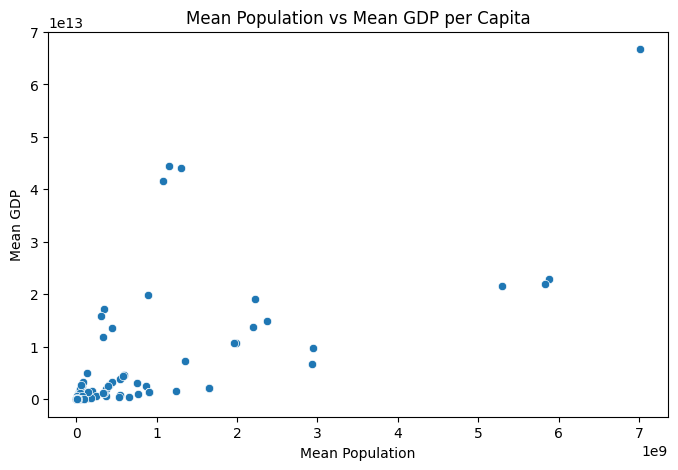

In [206]:
#Visualise Selling Price vs Kilometres Driven (not needed if below is available)
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=pop_gdp_analysis,
    x='Mean Population',
    y='Mean GDP'
)
plt.xlabel('Mean Population')
plt.ylabel('Mean GDP')
plt.title('Mean Population vs Mean GDP per Capita')
plt.show()

Most obseration are concentrated at lower population mean and low-medium mean GDP, with a relatively a few observations at a higher values.There os a noticable gap and the scatterplot becomes sparse as population incrreases, with severa; extreme observations separated from the main concentrations. Overall, an upward trend appear to be present, but this requieres further investigation of correlation.

## Pearson Correlation

In [207]:
# Correlation matrix

pop_gdp_analysis[['Mean Population', 'Mean GDP']].corr(method='pearson')

,Mean Population,Mean GDP
Mean Population,1.000000,0.719742
Mean GDP,0.719742,1.000000


with r = 0.719742 there is a strong positive linear correlation between mean population mean and mean gpd, indiacting that countries with higher mean mean population tend to have higher mean gpd in the dataset.

## Linear Regression
* Independent variable - mean population (predictor)
* Dependent varibale - mean GPD (target)


In [ ]:
# Define X and y 

X = pop_gdp_analysis[['Mean Population']]
y =pop_gdp_analysis[['Mean GDP']]

In [ ]:
# Crete and Fit the model (fitting a line through the dataset observaiton)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [216]:
# Regression equation

print('Intercept:', model.intercept_)
print('Coefficient:', model.coef_[0])

Intercept: [4.70354933e+11]
Coefficient: [5988.45140682]


In [217]:
# Model evalaution 

r_squared = model.score(X,y)
print('R²:',r_squared)

R²: 0.5180285947268881


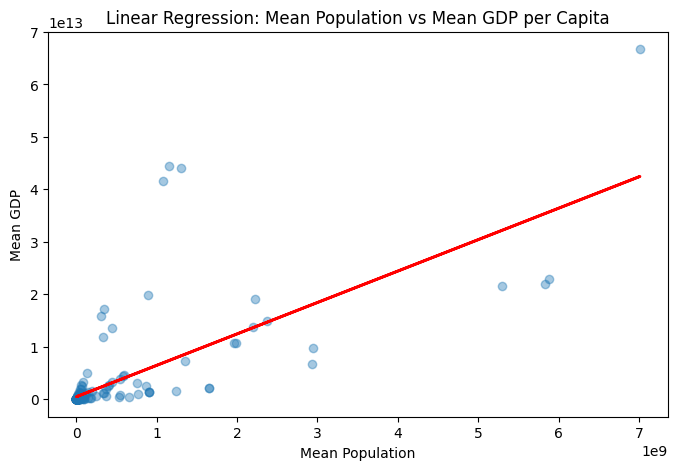

In [220]:
# Plotting regression line
y_predict = model.predict(X)

plt.figure(figsize=(8, 5))

plt.scatter(X['Mean Population'], y, alpha=0.4)

plt.plot(
    X['Mean Population'], y_predict, color='red', linewidth=2)

plt.xlabel('Mean Population')
plt.ylabel('Mean GDP')
plt.title('Linear Regression: Mean Population vs Mean GDP per Capita')
plt.show()